# Skin Cancer MNIST: HAM10000


The Skin Cancer MNIST: HAM10000 dataset contains over 10.000 pictures of skin lesions. Each picture is labeled as one of seven types, including both benign and malignant lesions. Some labels are confirmed with lab tests, while others are checked by doctors. This dataset is useful for training and testing machine learning models to detect and classify skin cancer. It is widely used in research because it is large, diverse, and realistic.

## First steps

### Libraries

In [1]:
import os

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

/home/haizea_gonzalez/Cuarto/segundoCuatri/ml_avanzado/deliverables/deliverable1/Advanced-ML-Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load the data

Since we will be working with images and don’t want to overload the repository, we will load the dataset directly from the option provided by [Kaggle](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000).

In [2]:
# Download from Kaggle the latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

# Create the full path to the metadata CSV file
csv_file = os.path.join(path, "HAM10000_metadata.csv")

# Load the metadata into a pandas DataFrame
df = pd.read_csv(csv_file)

# Display the first few rows of the DataFrame to verify it loaded correctly
print(df.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


### Data Cleaning

As the dataset is splitted into two folders ('ham10000_images_part_1' and 'ham10000_images_part_2'), we will define the paths to both folders to ensure we can find any image regardless of which part it is in.

In [3]:
part1_path = os.path.join(path, "ham10000_images_part_1")
part2_path = os.path.join(path, "ham10000_images_part_2")

We will create a function that takes an image_id and returns the full path to the corresponding image, automatically checking both folders (ham10000_images_part_1 and ham10000_images_part_2).

In [4]:
def get_image_path(image_id):
    """
    Get the full path of a skin lesion image given its image ID.

    This function searches for the image in both dataset folders
    ('ham10000_images_part_1' and 'ham10000_images_part_2') and
    returns the absolute path once found.

    Parameters
    ----------
    image_id (str): The ID of the image (without the '.jpg' extension), e.g., 'ISIC_0000000'.

    Returns
    -------
    str
        Full path to the image file.

    Notes
    -----
    - If the image does not exist in either folder, the returned path
      will point to a non-existent file. You may want to check
      os.path.exists() before opening the image.
    """
    
    
    # Get the image name by appending '.jpg' to the image_id
    img_name = image_id + ".jpg"
    
    # Check if the image exists in part 1, if not check in part 2
    img_path = os.path.join(part1_path, img_name)
    if not os.path.exists(img_path):
        img_path = os.path.join(part2_path, img_name)
        
    return img_path

In [5]:
# Apply the function to create a new column 'image_path' in the DataFrame
df['image_path'] = df['image_id'].apply(get_image_path)

#### Null Values

As in any project, it is important to check for null values and decide how to deal with them if needed.

In [6]:
# Get null values
df_nulls = df[df.isnull().any(axis=1)]

print(f"There are {len(df_nulls)} rows with null values.\n")
print(f"It is the {len(df_nulls)/len(df)*100:.2f}% of the rows.\n")
print(df_nulls[['image_id', 'lesion_id', 'age', 'dx']])

null_ids = df_nulls['image_id'].tolist()
print("\nNull IDs:")
print(null_ids)

There are 57 rows with null values.

It is the 0.57% of the rows.

          image_id    lesion_id  age   dx
968   ISIC_0033391  HAM_0001186  NaN  bkl
969   ISIC_0033750  HAM_0002660  NaN  bkl
970   ISIC_0033685  HAM_0000372  NaN  bkl
971   ISIC_0033631  HAM_0000948  NaN  bkl
972   ISIC_0033490  HAM_0000983  NaN  bkl
973   ISIC_0034283  HAM_0007281  NaN  bkl
974   ISIC_0032740  HAM_0001561  NaN  bkl
975   ISIC_0034186  HAM_0000825  NaN  bkl
977   ISIC_0034252  HAM_0006074  NaN  bkl
978   ISIC_0033829  HAM_0006074  NaN  bkl
1886  ISIC_0032960  HAM_0000169  NaN  mel
1887  ISIC_0033708  HAM_0000169  NaN  mel
7558  ISIC_0025009  HAM_0007278  NaN   nv
7961  ISIC_0033442  HAM_0002417  NaN   nv
7962  ISIC_0032943  HAM_0002417  NaN   nv
8410  ISIC_0031725  HAM_0006706  NaN   nv
8411  ISIC_0027040  HAM_0004924  NaN   nv
8555  ISIC_0032300  HAM_0007278  NaN   nv
9386  ISIC_0031668  HAM_0000698  NaN   nv
9387  ISIC_0027431  HAM_0000698  NaN   nv
9593  ISIC_0033374  HAM_0006766  NaN   nv
9594  ISI

As we can see, there are 57 null values. However, considering there are about 10,000 rows and these values represent only 0.57%, **we will remove them so they do not affect the analysis**.

### Visualizing Dataset Samples
After configuring the image paths, we visualize a sample to better understand the visual characteristics of the skin lesions. The HAM10000 dataset contains a wide variety of colors, textures, and shapes. Observing these raw images helps us anticipate the features the CNN will need to extract for accurate classification.

First, we are going to create a function to display any image based on its image ID:

In [7]:
def show_image(image_id, df):
    """
    Display a skin lesion image along with its diagnosis.

    This function checks whether the provided image ID exists in the DataFrame
    and whether the corresponding image file exists in the dataset. If both
    conditions are met, the image is displayed using matplotlib with its diagnosis.

    Parameters
    ----------
    image_id (str): The ID of the image to display (without '.jpg'), e.g., 'ISIC_0027419'.
    df (pandas.DataFrame): The DataFrame containing metadata, including 'dx' (diagnosis)
        and 'image_path' (full path to the image file).

    Returns
    -------
    None
        Displays the image if available. Prints an error message if the
        image ID does not exist in the DataFrame or if the image file is missing.


    Notes
    -----
    - The function safely handles missing image IDs and missing image files.
    - Requires the DataFrame to have a column 'image_path' with full paths
      to each image.
    """
    # Get the full path of the image
    row = df.loc[df['image_id'] == image_id]
    
    if row.empty:
        print(f"Error: Image ID {image_id} not found in the DataFrame.")
        return
    
    sample_image_path = row['image_path'].values[0]


    # Check if the image exists
    if os.path.exists(sample_image_path):
        img = Image.open(sample_image_path)
        plt.imshow(img)
        plt.axis('off')  # Hide axes
        diagnosis = df.loc[df['image_id'] == image_id, 'dx'].values[0]
        plt.title(f"Diagnosis: {diagnosis} | ID: {image_id}")
        plt.show()
    else:
        print(f"Error: Image {image_id} not found in the dataset.")

Now, we can check any raw image by entering its ID:

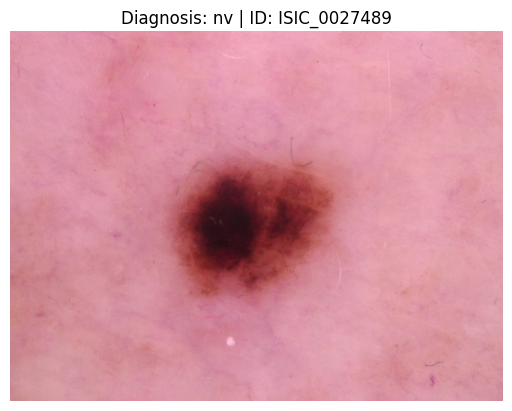

In [8]:
show_image("ISIC_0027489", df)

## Understanding the data

In this section, we are going to explore the columns of the dataset and inspect their contents. It is important to clearly understand the columns in order to know how to approach the problem.

In [9]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/home/haizea_gonzalez/.cache/kagglehub/dataset...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/home/haizea_gonzalez/.cache/kagglehub/dataset...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/home/haizea_gonzalez/.cache/kagglehub/dataset...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/home/haizea_gonzalez/.cache/kagglehub/dataset...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/home/haizea_gonzalez/.cache/kagglehub/dataset...


The columns we have are:
- ***lesion_id***: Unique identifier of the lesion → TYPE string

- ***image_id***: Unique identifier of the image → TYPE string

- ***dx***: Diagnosis of the lesion. Useful for lesion classification → TYPE string
    
    **Benign**
    - **nv**: Melanocytic nevus (benign mole)
    - **bkl**: Benign keratosis-like lesions
    - **vasc**: Vascular lesion
    - **df**: Dermatofibroma (benign skin lesion)

    **Malignant**
    - **mel**: Melanoma (malignant skin cancer)
    - **bcc**: Basal cell carcinoma (skin cancer)
    - **akiec**: Actinic keratoses / intraepithelial carcinoma




- ***dx_type***: Indicates how the diagnosis was confirmed. Helps assess the reliability of the diagnosis → TYPE string
    - **histo**: Confirmed by histopathology (laboratory test)
    - **follow_up**: Confirmed by clinical follow-up
    - **consensus**: Confirmed by expert consensus
    - **confocal**: Confirmed by confocal microscopy

    With *histo* generally considered more reliable than *follow_up*, while less common values such as *consensus* and *confocal* indicate specialized confirmation.

- ***age***: Age of the patient in years → TYPE float

- ***sex***: Sex of the patient ('male', 'female', 'unknown') → TYPE string

- ***localization***: Anatomical location of the lesion on the body → TYPE string

- ***imag_path***: Full path to the image file in the dataset → TYPE string

### Exploratory Data Analysis

In this section we are going to get insights about the dataset. These will be very useful to know more about the data and to select the best way to go ahead with the problem.

#### Diagnosis distribution

##### Benign VS Malignant

One of the best ways to understand the data is to check for class imbalances, which can be easily visualized using a simple but effective distribution plot.

/tmp/ipykernel_26240/214184989.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='benign_malign', data=df, palette='coolwarm')


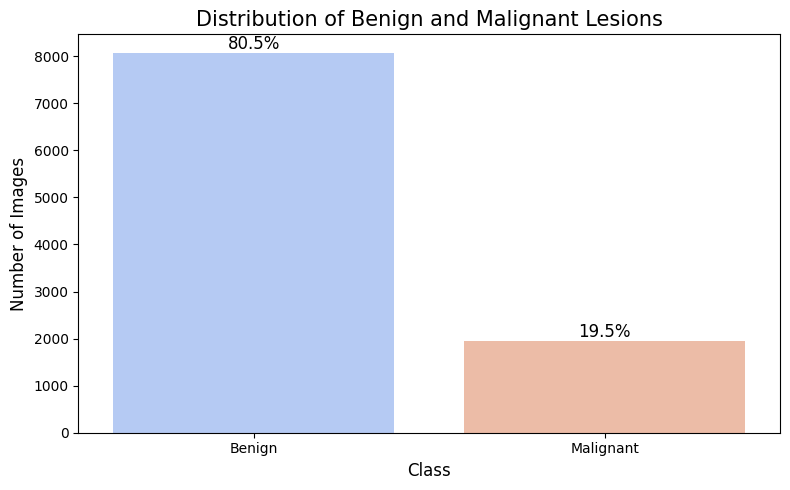

Distribution of Benign and Malignant Lesions:
 benign_malign
Benign       8061
Malignant    1954
Name: count, dtype: int64


In [10]:
# Get malignant classes
malignant = ['mel', 'bcc', 'akiec']

# Create binary column for benign vs malignant
df['benign_malign'] = df['dx'].apply(lambda x: 'Malignant' if x in malignant else 'Benign')

percentages = df['benign_malign'].value_counts(normalize=True) * 100

# Plot benign vs malignant
plt.figure(figsize=(8, 5))
sns.countplot(x='benign_malign', data=df, palette='coolwarm')

# Add percentages on top of bars
total = len(df)
for p in plt.gca().patches:
    height = p.get_height()
    percentage = height / total * 100
    plt.gca().annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2, height),
                       ha='center', va='bottom', fontsize=12)

plt.title('Distribution of Benign and Malignant Lesions', fontsize=15)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.tight_layout()
plt.show()

# Count for report
print("Distribution of Benign and Malignant Lesions:\n", df['benign_malign'].value_counts())

As we see in the barplot, most of the samples are classified as Bening (80.5%). But to get deeper insights, we made additional plots so we can predict more precisely whether a cancer is malignant or benign, just from its image.

##### Lesion type distribution

We will repeat this plot among the seven different types of skin lesions in the dataset.

/tmp/ipykernel_26240/594728644.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='cell_type', data=df, order=df['cell_type'].value_counts().index, palette='magma')


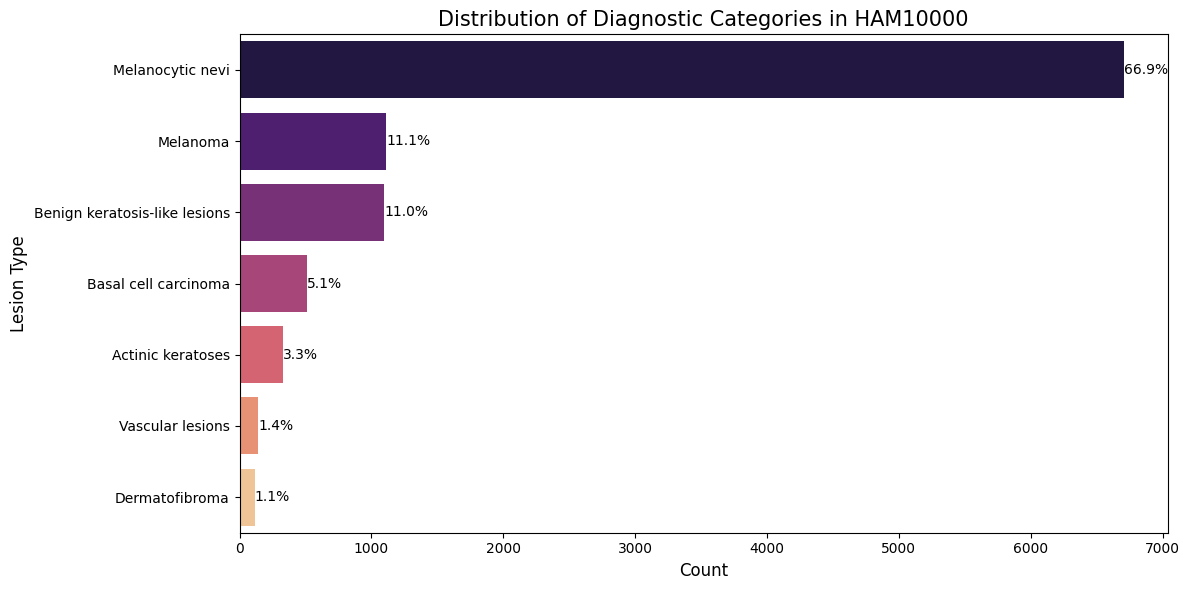

Class distribution:
 cell_type
Melanocytic nevi                 6705
Melanoma                         1113
Benign keratosis-like lesions    1099
Basal cell carcinoma              514
Actinic keratoses                 327
Vascular lesions                  142
Dermatofibroma                    115
Name: count, dtype: int64


In [11]:
# Mapping dictionary for full diagnostic names
dx_map = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

# Add a more descriptive column
df['cell_type'] = df['dx'].map(dx_map)

# Plotting the distribution
plt.figure(figsize=(12, 6))
sns.countplot(y='cell_type', data=df, order=df['cell_type'].value_counts().index, palette='magma')

# Add percentages on top of bars
total = len(df)
for p in plt.gca().patches:
    width = p.get_width()
    percentage = width / total * 100
    plt.gca().annotate(f'{percentage:.1f}%', (width, p.get_y() + p.get_height() / 2),
                       ha='left', va='center', fontsize=10)

plt.title('Distribution of Diagnostic Categories in HAM10000', fontsize=15)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Lesion Type', fontsize=12)
plt.tight_layout()
plt.show()

# Print class counts for report
print("Class distribution:\n", df['cell_type'].value_counts())

The plot shows a significant class **imbalance among the seven classes**. Most of the samples are benign, with 'Melanocytic nevi' being the largest class. If we focus only on the malignant types [Melanoma (mel), Basal cell carcinoma (bcc), and Actinic keratoses (akiec)] we can see that these classes have fewer samples compared to the benign ones. This is a critical observation for our project, as it highlights the need for Data Augmentation and more robust evaluation metrics (such as F1-Score) to ensure the model doesn't simply bias towards the most frequent class.

#### Characteristics distribution

It is also useful to examine the distribution of numerical features. For instance, in this dataset, age may influence whether a lesion is benign or malignant, and such patterns can be detected through exploratory plots.

##### Age distribution Boxplot

We start with a boxplot to visualize the distribution of age for benign and malignant lesions. Boxplots provide a clear view of the median, interquartile range, and potential outliers, giving a quick summary of the age differences between classes.

/tmp/ipykernel_26240/2001720711.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='benign_malign', y='age', data=df, palette='coolwarm')


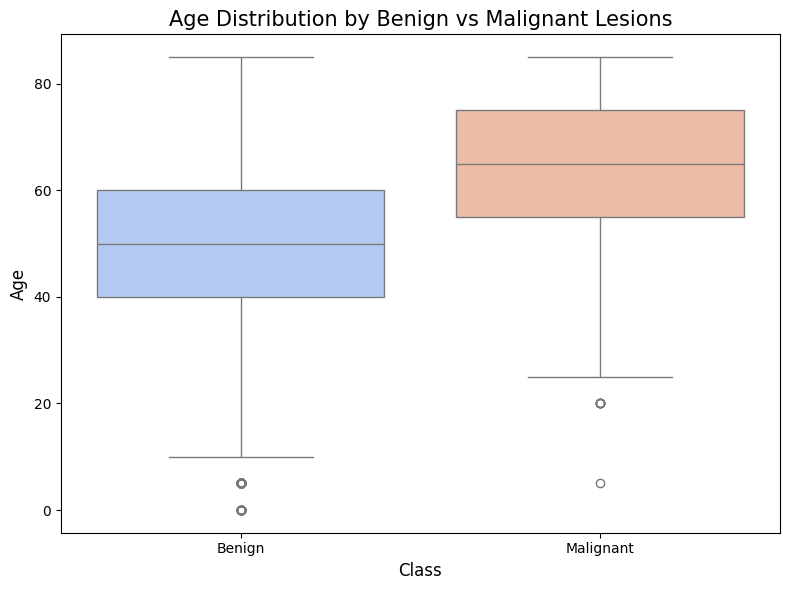

                count       mean        std  min   25%   50%   75%   max
benign_malign                                                           
Benign         8006.0  49.080689  16.344335  0.0  40.0  50.0  60.0  85.0
Malignant      1952.0  63.278689  14.534753  5.0  55.0  65.0  75.0  85.0


In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(x='benign_malign', y='age', data=df, palette='coolwarm')
plt.title('Age Distribution by Benign vs Malignant Lesions', fontsize=15)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.tight_layout()
plt.show()

# Print age statistics by class for report
print(df.groupby('benign_malign')['age'].describe())

As shown by the descriptive statistics and the visualization, **age appears to influence** whether a lesion is benign or malignant. The mean age for benign lesions is approximately 49 years, while for malignant lesions it is about 63 years. Additionally, the interquartile ranges show that malignant lesions tend to occur at older ages, with 50% of malignant cases between 55 and 75 years. This supports the hypothesis that age is associated with malignancy in this dataset.

We can also observe that there are a few **outliers** in both categories. Some benign cases are as young as 0–5 years, and malignant cases include patients as young as 5 and 20 years. To further investigate the age distribution and identify potential outliers, we used the same boxplot combined with a stripplot.

The **stripplot** adds individual data points, allowing us to observe the density and spread of each sample. This visualization helps verify whether unusually young or old cases are genuine or possible data entry errors, providing a more detailed understanding of age differences between benign and malignant lesions.

/tmp/ipykernel_26240/3237298645.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='benign_malign', y='age', data=df, palette='coolwarm', showfliers=True)


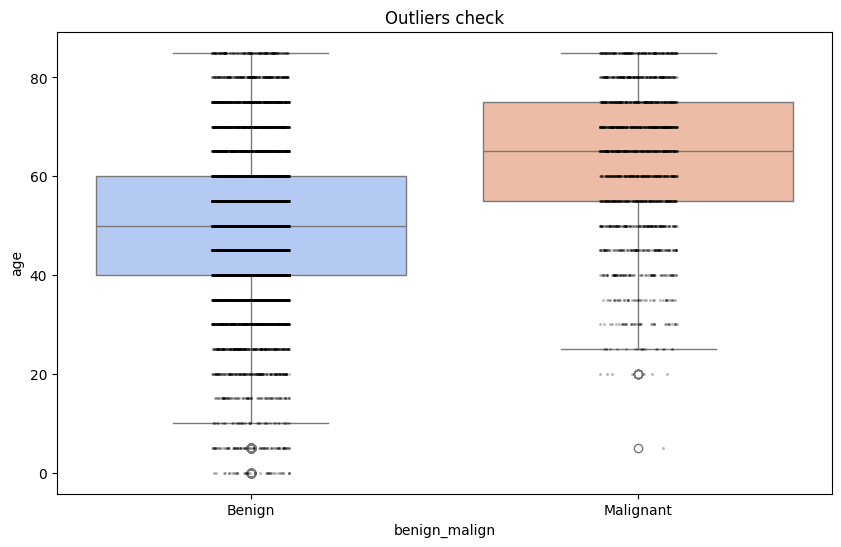

In [13]:
plt.figure(figsize=(10, 6)) 
sns.boxplot(x='benign_malign', y='age', data=df, palette='coolwarm', showfliers=True)

# Density layer
sns.stripplot(x='benign_malign', y='age', data=df, color='black', size=2, alpha=0.3)
plt.title('Outliers check')
plt.show()

The black points far from the boxes (especially near 0) explain why the boxplot looked unusual at first.
- **For benign lesions**, it is normal to see many young children with ages around 0–5 years, as these usually correspond to birthmarks or vascular lesions.

- **For malignant lesions**, points at low ages are unusual, since skin cancer is extremely rare in children. These points are the “exceptions” to the general pattern.

In summary, the plot shows that most malignant cases occur in older individuals, but the isolated black points at younger ages remind us that there are **true exceptions**, which we will not remove, as the model must also be able to detect them.


##### Kerner Density Estimate

Now, we will use a KDE plot to observe the overall shape of the age distribution for each class. This allows us to see patterns, and make sure that certain age ranges are more common for malignant or benign lesions.

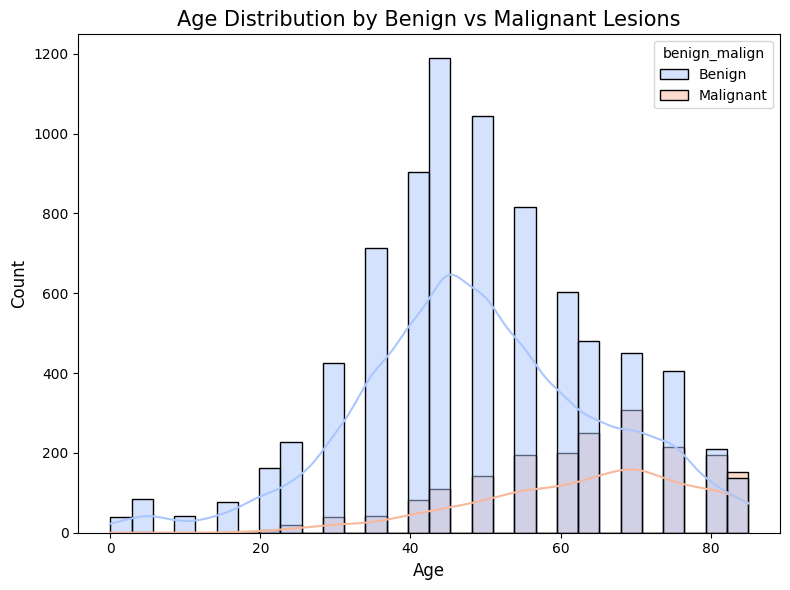

In [14]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='age', hue='benign_malign', kde=True, 
             bins=30, palette='coolwarm', alpha=0.5)
plt.title('Age Distribution by Benign vs Malignant Lesions', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

The KDE plot also shows that benign lesions usually happen at younger ages than malignant ones. The distribution of benign cases is bell-shaped, meaning that most cases are around the same age, even though it’s not a perfect bell. On the other hand, malignant cases have a more irregular distribution, showing that they can appear over a wider range of ages.

##### Normalized KDE

Finally, we use a normalized KDE plot to compare the ages of benign and malignant lesions. This lets us focus on the shape of the age distributions without being affected by the number of cases in each class.

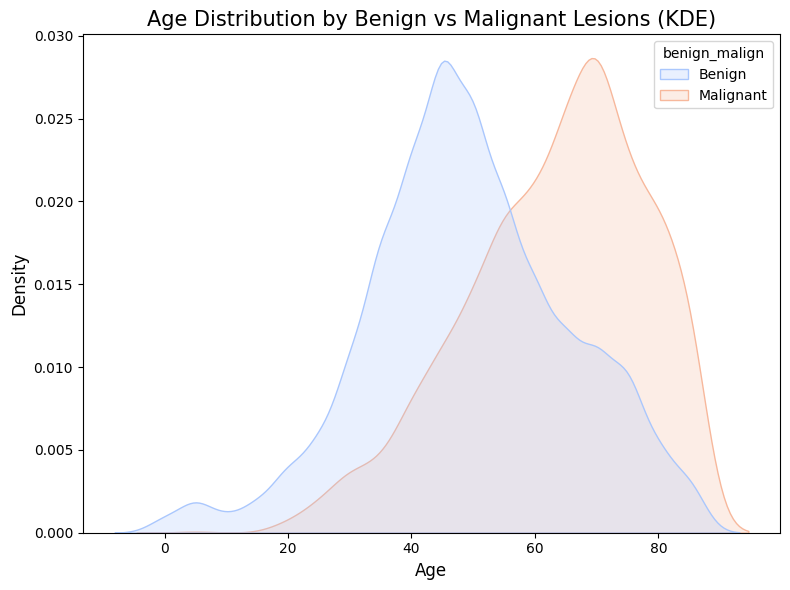

In [15]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df, x='age', hue='benign_malign', palette='coolwarm', fill=True, common_norm=False)
plt.title('Age Distribution by Benign vs Malignant Lesions (KDE)', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.show()

The plot shows that benign lesions usually occur at younger ages with a roughly bell-shaped pattern, while malignant lesions are more spread out. This supports the idea that age is related to whether a lesion is benign or malignant.

##### Correlation Heatmap: Location VS Diagnosis 

Now, we are going to use a correlation heatmap to see if each class tends to appear more frequently in a specific body location. This will be useful, as it could be used as an additional feature in the model to improve its predictions.

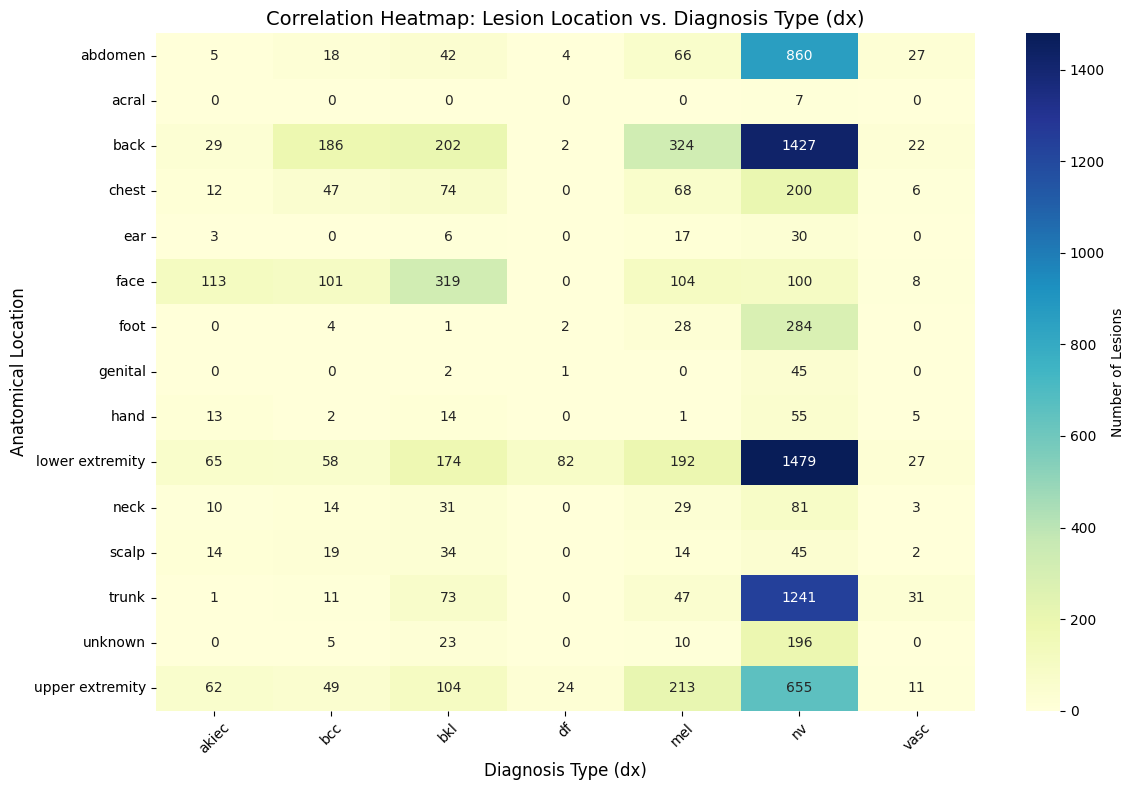

In [16]:
# Contingency table for localization vs diagnosis (needed as are categorical variables)
contingency_table = pd.crosstab(df['localization'], df['dx'])

# Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    contingency_table, 
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    cbar_kws={'label': 'Number of Lesions'}
)

# Add labels and title
plt.title('Correlation Heatmap: Lesion Location vs. Diagnosis Type (dx)', fontsize=14)
plt.xlabel('Diagnosis Type (dx)', fontsize=12)
plt.ylabel('Anatomical Location', fontsize=12)

# Rotate labels so they do not overlap
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()

From the plot, we can see that certain classes tend to appear more frequently in specific body areas. For example, 'Melanocytic nevi' are mostly found on the trunk and lower limbs, while 'Basal cell carcinoma' occurs more often on the head and neck.

However, **to avoid misleading conclusions** due to the large differences in class sizes, we will normalize the counts by column to show the proportion of each diagnosis within each anatomical location. This will allow us to see which classes are relatively more common in each location, independently of their overall frequency. **Normalizing by column** ensures that we can identify the anatomical areas where each diagnosis is relatively concentrated, rather than being dominated by the larger classes. This information could be useful as an additional feature to improve the predictive performance of the model.

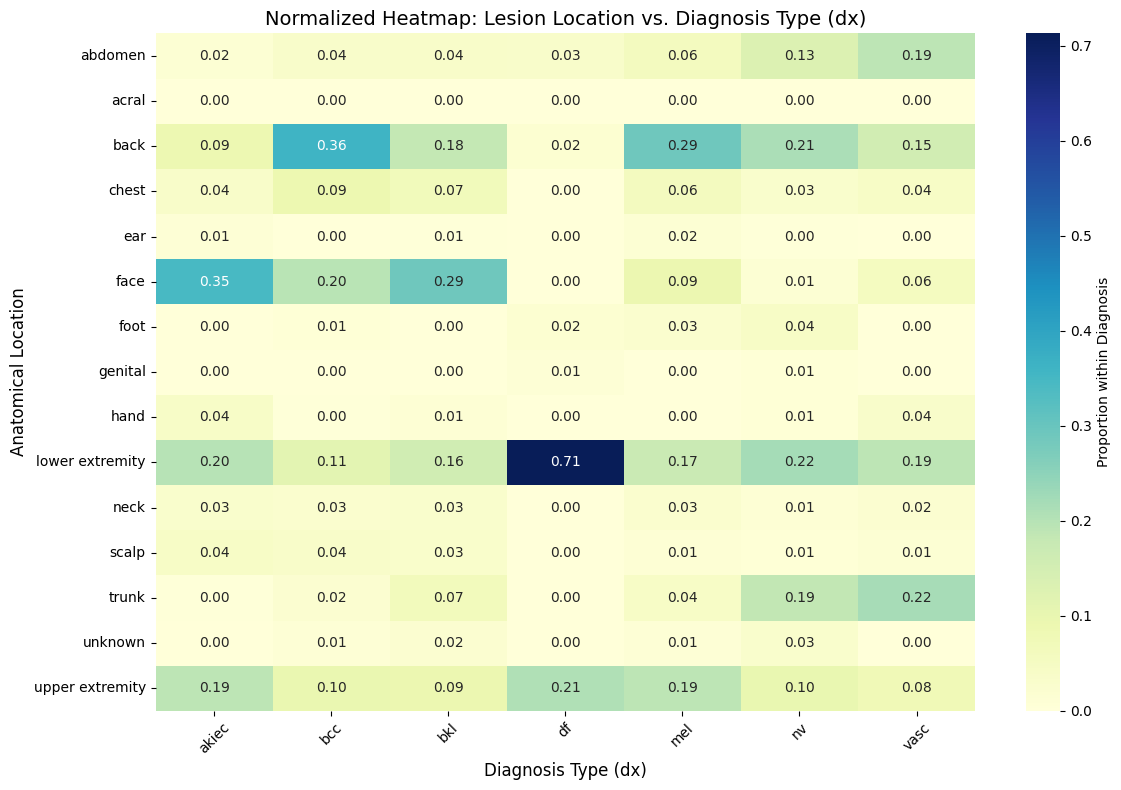

In [17]:
# Normalize the contingency table by row to see the distribution of diagnoses within each location
contingency_table_norm = pd.crosstab(df['localization'], df['dx'], normalize='columns')

# Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    contingency_table_norm,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Proportion within Diagnosis'}
)

# Add labels and title
plt.title('Normalized Heatmap: Lesion Location vs. Diagnosis Type (dx)', fontsize=14)
plt.xlabel('Diagnosis Type (dx)', fontsize=12)
plt.ylabel('Anatomical Location', fontsize=12)

# Rotate labels so they do not overlap
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()

From the normalized table, we can see that **some diagnoses are strongly associated with specific locations**. For example, Dermatofibromas are mostly on the lower extremities, and Actinic keratoses are mainly on the face. Other classes, like Melanoma and Melanocytic nevi, are more spread out but still show higher proportions on the back and lower extremities. This suggests that **anatomical location could be a useful additional feature for the model**, as it may help improve predictions for certain lesion types.

##### Distribution by Anatomical Location

To better understand the relationship between anatomical location and lesion type, we created a plot showing the proportion of benign and malignant lesions for each body location.

In this case, **normalization by row (localization)** is necessary because most lesions in the dataset are benign, and using absolute counts would make it difficult to identify locations with a higher relative proportion of malignant cases. By normalizing, each row sums to 1, allowing us to clearly see the percentage of malignant vs benign lesions in each location. This approach provides a more accurate view of which locations may be more strongly associated with malignancy and can be useful as an additional feature in the predictive model. Based on the previous heatmap with detailed diagnoses, we observed that **normalization improves interpretability and highlights meaningful patterns that are not visible when using raw counts**.

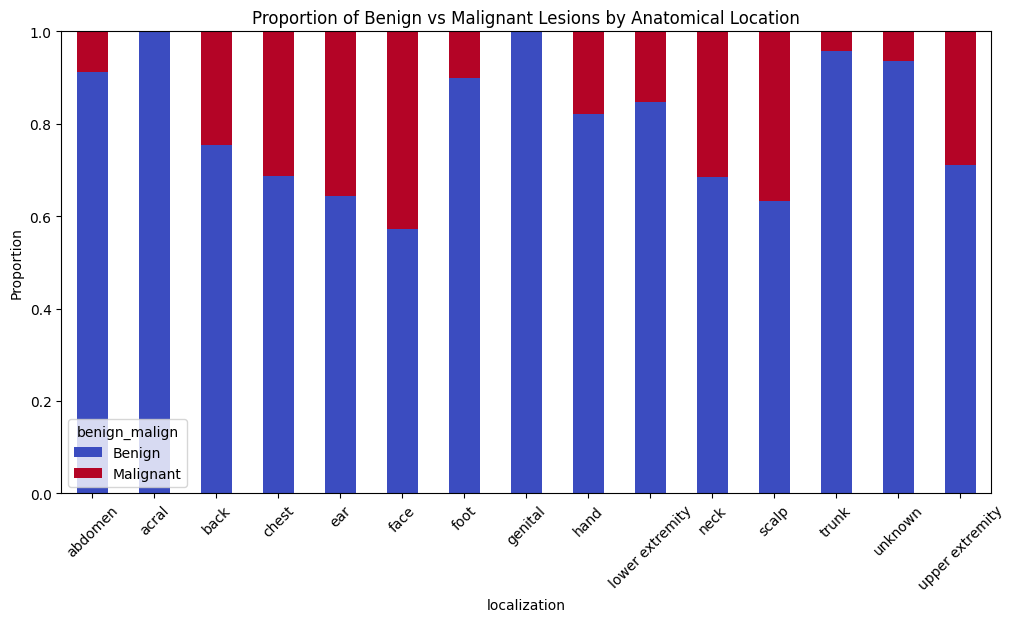

In [18]:
# Normalize per column to see the distribution of locations within each diagnosis
contingency = pd.crosstab(df['localization'], df['benign_malign'], normalize='index')

# Bar plot with proportions
contingency.plot(kind='bar', stacked=True, figsize=(12,6), colormap='coolwarm')
plt.ylabel('Proportion')
plt.title('Proportion of Benign vs Malignant Lesions by Anatomical Location')
plt.xticks(rotation=45)
plt.show()

As we can see in the plot, locations like the face, ear, scalp, chest and neck have a higher proportion of malignant lesions, while areas such as the abdomen, trunk, and foot are mostly benign. Small locations like genital, or acral regions have very few (although it is not visible in the plot, if we print the contingency table, there is a few percentage) we malignant cases. Normalizing by location allows us to see the relative proportion of malignancy, avoiding misleading results due to the large number of benign lesions. This suggests that **anatomical location could be used as an additional feature in the model**, as it provides useful information about the likelihood of a lesion being malignant in specific body areas.

##### Correlation Heatmap: Location VS Sex 

To have more insight into the dataset, we are analyzing how sex is distributed across different anatomical locations. By creating a normalized heatmap, we can see the proportion of males and females in each location. This helps identify potential patterns, such as certain locations being more common in one sex, which could be useful as an additional feature in the predictive model. As we saw in previous plots, normalization ensures that differences in sample sizes between locations do not distort the interpretation.

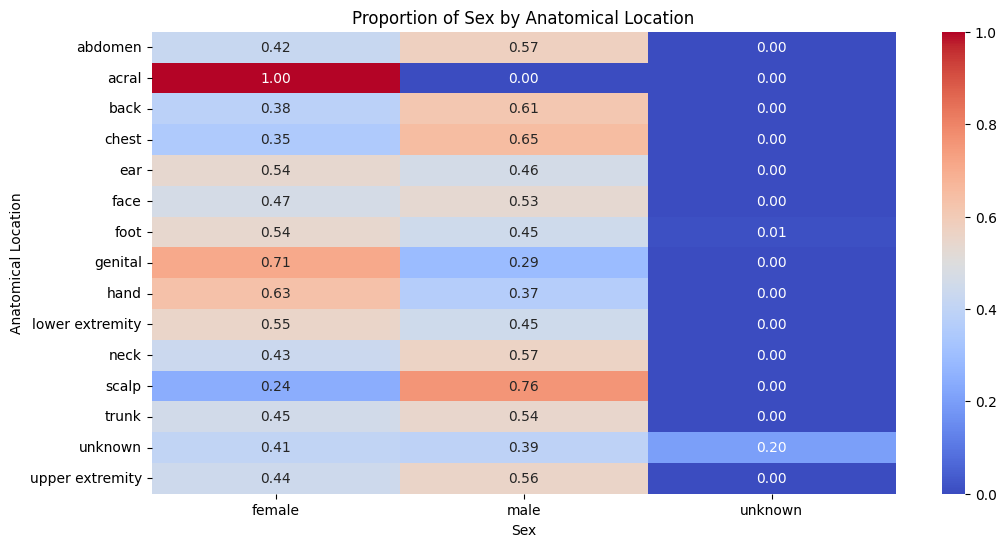

In [19]:
# Contingency table
contingency = pd.crosstab(df['localization'], df['sex'], normalize='index')

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(contingency, annot=True, fmt='.2f', cmap='coolwarm')

# Add labels and title
plt.title('Proportion of Sex by Anatomical Location')
plt.ylabel('Anatomical Location')
plt.xlabel('Sex')

# Show the plot
plt.show()

As we can see, all lesions in the acral region are female in this dataset, while the scalp is mostly male (≈76%). Other locations, like the abdomen, face, and trunk, are more balanced between sexes. Small categories or locations with few samples may show extreme proportions but are less reliable. These patterns suggest that sex could be related to lesion location and may be considered as an additional feature in the predictive model.

##### Correlation Heatmap: Benign/Malignant VS Sex 

We think it is also important to understand the relationship between sex and lesion type. To do this, we will examine the distribution of benign and malignant lesions across sexes.

We normalized the contingency table by row, that is, by benign and malignant lesions, to show the proportion of males and females within each lesion type. This allows us to see the sex distribution for benign and malignant lesions separately, without being affected by the larger number of benign cases.

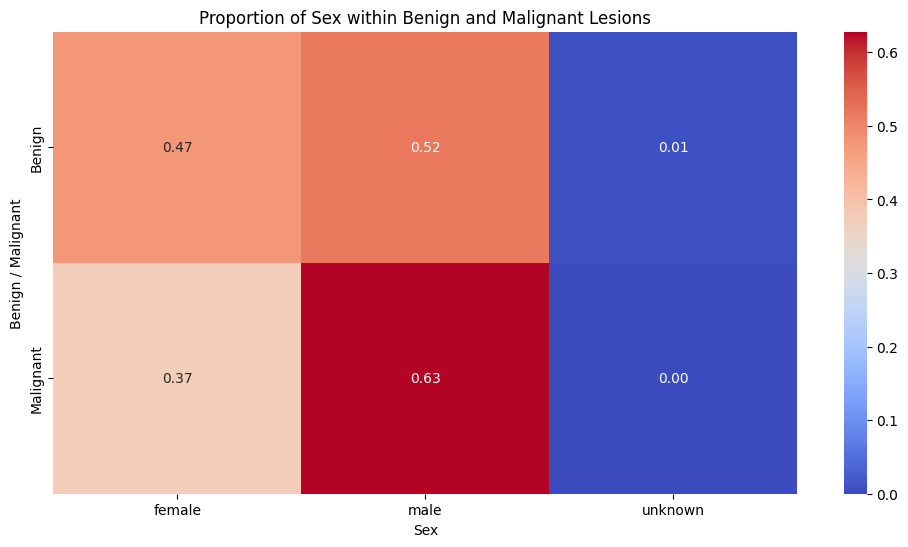

In [20]:
# Contingency table
contingency = pd.crosstab(df['benign_malign'], df['sex'], normalize='index')

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(contingency, annot=True, fmt='.2f', cmap='coolwarm')

# Add labels and title
plt.title('Proportion of Sex within Benign and Malignant Lesions')
plt.ylabel('Benign / Malignant')
plt.xlabel('Sex')

# Show the plot
plt.show()

The plot shows the proportion of females, males, and unknown within benign and malignant lesions. Among benign lesions, females and males are roughly balanced (≈47% vs 52%), while malignant lesions are more common in males (≈63%). Unknown sex is very small and mostly present in benign cases. This suggests that sex could have some relationship with malignancy, which may be useful as an additional feature in the model.

# Conclusions

As we have seen, there is a **big data imbalance** between lesion classes and between benign and malignant cases. To handle it, we may need SMOTE, data augmentation, or GAN-generated images to improve the model and help it detect rare classes.

On the other hand, the EDA helps answer some key questions: which features should we use in the model?

1. **Image (the main feature)**: It is the key aspect of the project. Without it, there is no diagnosis.

2. **Age**: As we saw, it is highly relevant. Analysis shows a clear correlation with malignancy Malignant lesions appear in older patients (mean ~63 years) compared to benign ones (~49 years). Boxplots and KDE plots confirm this. For the model: include age as a numerical feature to improve class differentiation, especially for borderline cases.

3. **Sex**: It is relevant, with some caution. Heatmaps show malignant lesions are more common in males (~63% vs 37%). Unknown sex is rare and should be handled carefully (for example, impute or treat as a separate category). For the model: include sex as a categorical feature in the multimodal model.

4. **Anatomical Location**: It is highly relevant. Proportion analysis shows some body areas are more prone to malignancy (face, ears, scalp), while others mostly have benign lesions (trunk, lower limbs). This allows the model to learn anatomical patterns, for example, a lesion on the face is more likely bcc or akiec.

5. **Diagnosis Method (dx_type)**: We will not use as input. This column describes how the diagnosis was obtained (biopsy, follow-up, consensus). Using it would cause data leakage, because in a real scenario you do not know this before prediction.

In summary, the image is the most important feature, while age, sex, and anatomical location provide useful additional information. The diagnosis method will not be used to avoid data leakage.

Considering the data imbalance, we will apply techniques like SMOTE, data augmentation, or GAN-generated images to improve the model and make it more reliable for rare classes.

With these features and strategies, we are ready to build a multimodal model that combines visual and contextual information for better lesion classification.